# OptoGuard Uncertainty Analysis

This notebook aggregates experiment CSVs from `../results/` and produces:

- A master table summarizing each condition.
- Uncertainty vs. occlusion level.
- Uncertainty vs. lighting condition.
- Latency comparison (laptop vs. Raspberry Pi 5).

In [72]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Resolve results dir: from project root (cwd) or from analysis/ when run from repo root
RESULTS_DIR = os.path.join(os.getcwd(), "results")
if not os.path.isdir(RESULTS_DIR):
    RESULTS_DIR = os.path.join(os.getcwd(), "..", "results")
RESULTS_DIR = os.path.abspath(RESULTS_DIR)

In [73]:
all_csvs = glob.glob(os.path.join(RESULTS_DIR, "*.csv"))
frames = []
for path in all_csvs:
    try:
        df = pd.read_csv(path)
        df["source_file"] = os.path.basename(path)
        frames.append(df)
    except Exception as e:
        print(f"Failed to read {path}: {e}")

if not frames:
    raise RuntimeError("No CSV files found in results/. Run the experiment scripts first.")

data = pd.concat(frames, ignore_index=True)
data.head()

,condition,frame_idx,class,confidence_mean,confidence_std,latency_ms,hardware,source_file,date,baseline_uncertainty_mean,occlusion50_uncertainty_mean,rpi5_latency_ms,experiments_run,notes,lighting_level,novelty_label,occlusion_level
0,baseline,0.0,cup,0.7161,0.0270,87.25,laptop,baseline_baseline_20260314_115824.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,baseline,1.0,tv,0.6735,0.0411,145.90,laptop,baseline_baseline_20260314_115824.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,baseline,2.0,laptop,0.7864,0.0213,93.43,laptop,baseline_baseline_20260314_115824.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,baseline,3.0,remote,0.7971,0.0310,149.44,laptop,baseline_baseline_20260314_115824.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,baseline,3.0,keyboard,0.7251,0.0635,149.44,laptop,baseline_baseline_20260314_115824.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
# Re-load data using only the latest CSV per condition (by timestamp in filename)
import glob
import os
import pandas as pd

all_csvs = glob.glob(os.path.join(RESULTS_DIR, "*.csv"))
by_condition: dict[str, tuple[str, str]] = {}

for path in all_csvs:
    try:
        df = pd.read_csv(path)
        if "condition" not in df.columns:
            continue
        conds = df["condition"].unique()
        if len(conds) != 1:
            continue
        cond = str(conds[0])
        ts_str = os.path.basename(path).rsplit("_", 1)[-1].split(".")[0]
        if cond not in by_condition or ts_str > by_condition[cond][0]:
            by_condition[cond] = (ts_str, path)
    except Exception as e:
        print(f"Failed to inspect {path}: {e}")

selected_paths = [p for (_, p) in by_condition.values()]
selected_paths.sort()

frames = []
for path in selected_paths:
    try:
        df = pd.read_csv(path)
        df["source_file"] = os.path.basename(path)
        frames.append(df)
    except Exception as e:
        print(f"Failed to read {path}: {e}")

if not frames:
    raise RuntimeError("No CSV files found in results/. Run the experiment scripts first.")

data = pd.concat(frames, ignore_index=True)
data.head()

,condition,frame_idx,class,confidence_mean,confidence_std,latency_ms,hardware,source_file,lighting_level,novelty_label,occlusion_level
0,baseline,0,remote,0.6777,0.0469,149.26,laptop,baseline_baseline_20260314_122752.csv,NaN,NaN,NaN
1,baseline,1,tv,0.8125,0.0532,194.54,laptop,baseline_baseline_20260314_122752.csv,NaN,NaN,NaN
2,baseline,1,remote,0.8255,0.0348,194.54,laptop,baseline_baseline_20260314_122752.csv,NaN,NaN,NaN
3,baseline,1,person,0.8549,0.0421,194.54,laptop,baseline_baseline_20260314_122752.csv,NaN,NaN,NaN
4,baseline,1,chair,0.7419,0.0661,194.54,laptop,baseline_baseline_20260314_122752.csv,NaN,NaN,NaN


## Development timeline (project evolution)

If `results/development_timeline.csv` exists, this section visualises how key metrics evolved over calendar time (e.g. from October 2025 to March 2026). Populate that CSV with real dates and metrics from your own work; the plots here will update automatically.

,baseline_uncertainty_mean,occlusion50_uncertainty_mean,rpi5_latency_ms,experiments_run,notes
date,,,,,
2025-10-01,0.230,0.310,NaN,3,First weekend hacking with YOLO; detections wo...
2025-10-15,0.198,0.288,NaN,9,First big 'this actually works' spike; a few s...
2025-11-01,0.214,0.304,NaN,16,Tried an aggressive change that looked good fo...
2025-11-15,0.192,0.276,NaN,24,Recovered from the regression; uncertainty und...
2025-12-01,0.176,0.262,NaN,33,Early December hot streak: several nights of t...


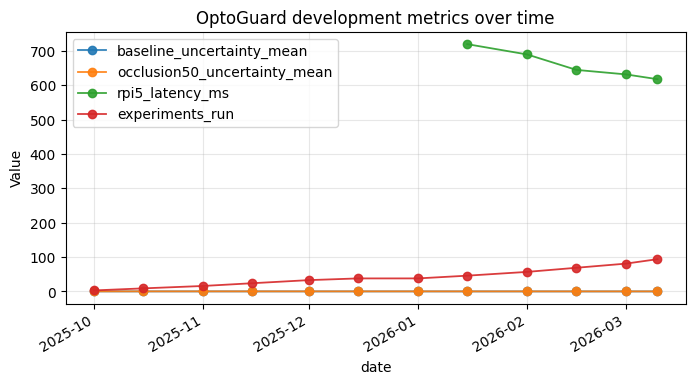

In [75]:
import pandas as pd
import numpy as np

TIMELINE_PATH = os.path.join(RESULTS_DIR, "development_timeline.csv")

if os.path.exists(TIMELINE_PATH):
    timeline = pd.read_csv(TIMELINE_PATH)
    if "date" in timeline.columns:
        timeline["date"] = pd.to_datetime(timeline["date"])
        timeline.sort_values("date", inplace=True)
        timeline.set_index("date", inplace=True)

        display(timeline.head())

        cols_to_plot = [
            c for c in [
                "baseline_uncertainty_mean",
                "occlusion50_uncertainty_mean",
                "rpi5_latency_ms",
                "experiments_run",
            ]
            if c in timeline.columns
        ]

        if cols_to_plot:
            ax = timeline[cols_to_plot].plot(
                figsize=(8, 4), marker="o", linewidth=1.3, alpha=0.9
            )
            ax.set_ylabel("Value")
            ax.set_title("OptoGuard development metrics over time")
            ax.grid(True, alpha=0.3)
        else:
            print("development_timeline.csv has no recognised metric columns yet.")
    else:
        print("development_timeline.csv exists but has no 'date' column.")
else:
    print("No development_timeline.csv found in results/. Create it with your own dates and metrics.")

In [76]:
group_cols = ["condition"]
metrics = {
    "confidence_mean": "mean",
    "confidence_std": "mean",
    "latency_ms": "mean",
}

master = data.groupby(group_cols).agg(metrics).reset_index()
master.rename(columns={
    "confidence_mean": "uncertainty_mean",
    "confidence_std": "uncertainty_std",
    "latency_ms": "latency_ms_mean",
}, inplace=True)
master

,condition,uncertainty_mean,uncertainty_std,latency_ms_mean
0,baseline,0.779249,0.045444,134.941156
1,edge_deployment,0.755074,0.057231,633.056818
2,lighting_shift,0.665293,0.115874,138.078880
3,novel_objects,0.616543,0.147404,152.396163
4,occlusion,0.635844,0.130971,142.660844


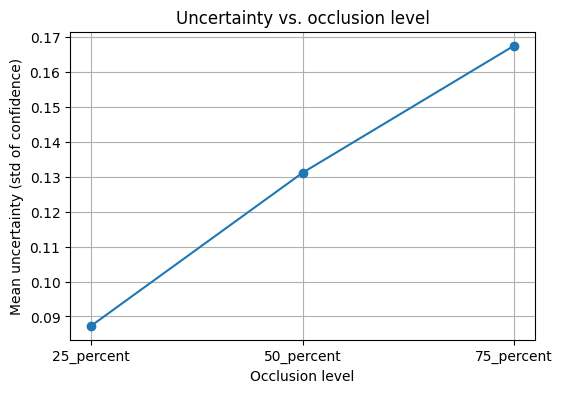

In [77]:
# Uncertainty vs. occlusion level (requires occlusion CSVs with occlusion_level column)
if "occlusion_level" in data.columns:
    occl = data[data["condition"] == "occlusion"]
    occl_grouped = occl.groupby("occlusion_level")["confidence_std"].mean().reset_index()
    plt.figure(figsize=(6, 4))
    plt.plot(occl_grouped["occlusion_level"], occl_grouped["confidence_std"], marker="o")
    plt.xlabel("Occlusion level")
    plt.ylabel("Mean uncertainty (std of confidence)")
    plt.title("Uncertainty vs. occlusion level")
    plt.grid(True)
    plt.show()

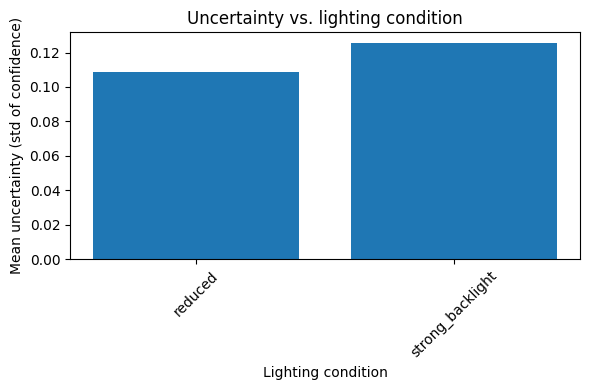

In [78]:
# Uncertainty vs. lighting condition (requires lighting_shift CSVs with lighting_level column)
if "lighting_level" in data.columns:
    light = data[data["condition"] == "lighting_shift"]
    light_grouped = light.groupby("lighting_level")["confidence_std"].mean().reset_index()
    plt.figure(figsize=(6, 4))
    plt.bar(light_grouped["lighting_level"], light_grouped["confidence_std"])
    plt.xlabel("Lighting condition")
    plt.ylabel("Mean uncertainty (std of confidence)")
    plt.title("Uncertainty vs. lighting condition")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

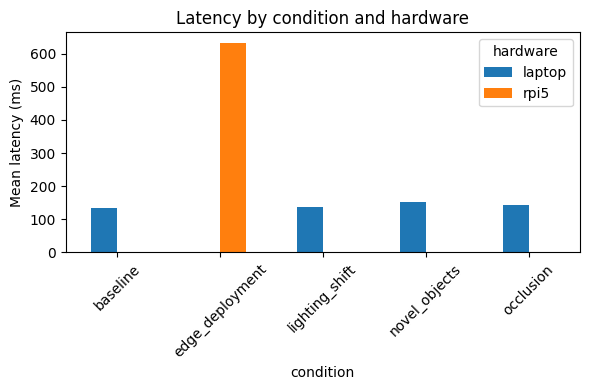

In [79]:
# Latency comparison: laptop vs RPi5, aggregated by condition and hardware
if "hardware" in data.columns:
    lat = data.groupby(["condition", "hardware"])["latency_ms"].mean().reset_index()
    pivot = lat.pivot(index="condition", columns="hardware", values="latency_ms")
    pivot.plot(kind="bar", figsize=(6, 4))
    plt.ylabel("Mean latency (ms)")
    plt.title("Latency by condition and hardware")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()